In [1]:
import tensorflow as tf
from tensorflow import keras

Obtener el dataset **Fashion MNIST** disponible en la **Keras API**

In [2]:
fashion_data = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

En este ejemplo, además de **entrenamiento** y **pruebas**, crearemos un conjunto de **validación** dividiendo aún más los datos de entrenamiento.

También escalaremos los valores (de 0 a 255 por defecto) a 0-1.

Realizaremos ambas tareas *manualmente*.

In [4]:
X_valid, X_train = X_train[:5000]/255.0, X_train[5000:]/255.0
y_valid, y_train = y_train[:5000], y_train[5000:]

¿Cuáles son las clases existentes en el dataset?

In [5]:
y_train

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

Esto no suena muy descriptivo... sin embargo, en el sitio [Web del dataset](https://github.com/zalandoresearch/fashion-mnist) tenemos información útil para asociar estas 10 classes con los tipos de prendas que representan.

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [7]:
# Show the actual class label for the first 10 training instances
for i in range(len(y_train[:10])):
  print(class_names[y_train[i]])

Coat
T-shirt/top
Sneaker
Ankle boot
Ankle boot
Ankle boot
Coat
Coat
Dress
Coat


**¡Ahora llega el momento de construir la arquitectura de la red neuronal!**

**PASO 1**: Crear el modelo y definir su arquitectura

In [8]:
my_model = keras.models.Sequential()
# Sequential model, a Keras ANN made of sequentially connected layers

my_model.add(keras.layers.Flatten(input_shape=[28, 28]))
# Add the first layer: an input layer with our 28x28 input attributes flattened into a 1x784 vector

my_model.add(keras.layers.Dense(300, activation="relu"))
# Add a dense hidden layer with 300 neurons and ReLU activation function

my_model.add(keras.layers.Dense(100, activation="relu"))
# Add another dense hidden layer (ReLU activation function)

my_model.add(keras.layers.Dense(10, activation="softmax"))
# Dense output layer, with one neuron per class and softmax activation function

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accedemos a información básica sobre un modelo definido anteriormente, incluidos los parámetros a entrenar, de la siguiente manera:

In [9]:
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

**PASO 2**: Compilar el modelo

Tras crear un modelo, debemos compilarlo, especificando la función de pérdida y el optimizer que queremos utilizar:

In [10]:
my_model.compile(loss = keras.losses.sparse_categorical_crossentropy,
                 optimizer = keras.optimizers.SGD(),
                 metrics = ["accuracy"]
                 )

**PASO 3**: Entrenar y evaluar el modelo

IMPORTANTE: Los datos de **validación** se utilizarán en la etapa de entrenamiento.

In [11]:
model_history = my_model.fit(X_train, y_train,
                          epochs=30, # The training runs 30 times through the entire training data
                          validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7648 - loss: 0.7189 - val_accuracy: 0.8280 - val_loss: 0.5102
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8292 - loss: 0.4912 - val_accuracy: 0.8460 - val_loss: 0.4559
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8435 - loss: 0.4471 - val_accuracy: 0.8452 - val_loss: 0.4412
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8537 - loss: 0.4192 - val_accuracy: 0.8664 - val_loss: 0.3951
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8606 - loss: 0.3991 - val_accuracy: 0.8684 - val_loss: 0.3834
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8663 - loss: 0.3826 - val_accuracy: 0.8726 - val_loss: 0.3692
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8691 - loss: 0.3704 - val_accuracy: 0.8712 - val_loss: 0.3731
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8739 - loss: 0.3576 - 

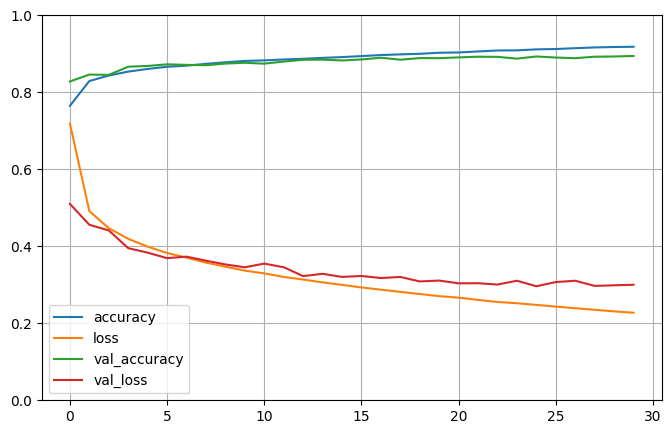

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(model_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) # Show the [0-1] range for the y axis
plt.show()

¿Qué **hiperparámetros** podemos ajustar para **mejorar el rendimiento del modelo** con **datos de validación** si no estamos muy satisfechos con el primero que hemos entrenado?

* **Ratio de aprendizaje** (probar varias opciones para cualquier configuración de los demás hiperparámetros). Por ejemplo:
*keras.optimizers.SGD(0.01)*
* La elección del **optimizer**, por ejemplo, SGD o cualquier otro.
* **Arquitectura de la ANN**: número de capas, número de neuronas por capa oculta, tipos de funciones de activación...

Una vez satisfechos con el rendimiento de los datos de validación, es momento de **evaluar los datos de prueba**.

In [13]:
X_test = X_test[:]/255.0
my_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8823 - loss: 0.3313


[0.3312869966030121, 0.8823000192642212]

Predicciones sencillas sobre unos pocos ejemplos de prueba:

In [14]:
X_new = X_test[:5]
y_proba = my_model.predict(X_new) # 'Predict' returns class probabilities per instance
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


array([[1.95915231e-06, 1.97389042e-07, 2.17512934e-06, 3.35919822e-06,
        6.11439054e-06, 2.85711372e-03, 5.07858601e-07, 4.67012124e-03,
        3.21794563e-04, 9.92136717e-01],
       [3.82009384e-05, 5.80011026e-08, 9.94409859e-01, 1.13365665e-07,
        2.40439456e-03, 6.27572772e-10, 3.14731291e-03, 4.12560854e-11,
        5.27380344e-08, 9.33454702e-12],
       [6.31804323e-06, 9.99989629e-01, 1.32181015e-06, 1.53805422e-06,
        1.20716004e-06, 9.31829874e-12, 1.04230251e-08, 3.30686589e-10,
        3.27289390e-10, 1.52732601e-11],
       [2.33138894e-06, 9.99920964e-01, 1.09409291e-06, 7.14074340e-05,
        3.93301252e-06, 6.03600991e-09, 2.88914947e-07, 1.43674184e-08,
        1.29256647e-10, 1.29184496e-09],
       [1.37177899e-01, 4.56674070e-06, 2.75483285e-03, 1.29990862e-03,
        1.31668174e-03, 1.17322152e-07, 8.57388914e-01, 5.36702132e-08,
        5.55662118e-05, 1.43167870e-06]], dtype=float32)

In [15]:
import numpy as np
y_predict = np.argmax(my_model.predict(X_new), axis=-1)
y_predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([9, 2, 1, 1, 6])

In [16]:
for i in range(len(y_predict)):
  print(class_names[y_predict[i]])

Ankle boot
Pullover
Trouser
Trouser
Shirt
